### ReAct Architecture

In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper


In [2]:
api_wrapper_arxiv= ArxivAPIWrapper(
    top_k_results=3, 
    doc_content_chars_max=500
)

arxiv=ArxivQueryRun(
    api_wrapper=api_wrapper_arxiv)

print(arxiv.name)

arxiv


In [3]:
api_wrapper_wiki= WikipediaAPIWrapper(
    top_k_results=3, 
    doc_content_chars_max=500
)

wiki=WikipediaQueryRun(
    api_wrapper=api_wrapper_wiki)

print(wiki.name)

wikipedia


In [5]:
### use tavily

from dotenv import load_dotenv
load_dotenv()

import os
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]= os.getenv("TAVILY_API_KEY")
os.environ["LANGCHAIN_API_KEY"]= os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"]= "true"
os.environ["LANGCHAIN_PROJECT"]= "ReAct Project"


In [6]:
## custom functions

def multiply(a: int, b: int) -> int:
    """Multiplies a and b,
    
    Args:
        a (int): First number.
        b (int): Second number."""
    return a * b


def add(a: int, b: int) -> int:
    """Adds a and b,
    
    Args:
        a (int): First number.
        b (int): Second number."""
    return a + b

def divide(a: int, b: int) -> float:
    """Divides a by b,
    
    Args:
        a (int): First number.
        b (int): Second number."""
    if b == 0:
        raise ValueError("Cannot divide by zero.")
    return a / b

In [19]:
### use tavily search tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily= TavilySearchResults()
# tools=[arxiv, wiki, tavily,add, multiply, divide ]

In [20]:
tools=[arxiv, wiki, tavily,add, multiply, divide ]

In [21]:
## initialize the llm model

from langchain_groq import ChatGroq

llm= ChatGroq(model="gemma2-9b-it")

llm_with_tools=llm.bind_tools(tools)


In [22]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the Weather of today")])



AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ne60jgp7n', 'function': {'arguments': '{"query":"Weather today"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 84, 'prompt_tokens': 1705, 'total_tokens': 1789, 'completion_time': 0.152727273, 'prompt_time': 0.072960052, 'queue_time': 0.274835089, 'total_time': 0.225687325}, 'model_name': 'gemma2-9b-it', 'system_fingerprint': 'fp_10c08bf97d', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--861d8f2a-dbef-4aa5-a908-a6386aae1f8f-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Weather today'}, 'id': 'ne60jgp7n', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1705, 'output_tokens': 84, 'total_tokens': 1789})

In [23]:
## State Schema

from typing import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    



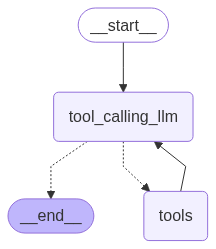

In [24]:
### entire chatbot with langgraphs

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


## build graph

builder = StateGraph(State)
builder.add_node(
    "tool_calling_llm",
    tool_calling_llm)

builder.add_node("tools", ToolNode(tools))


##adding the edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition, 
)

builder.add_edge("tools", "tool_calling_llm")  # here instead of end we will be using tool_calling_llm node

graph=builder.compile()


display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
messages=graph.invoke({"messages":HumanMessage(content="give me top 10 ai news in june. Add 5+5 and then multiply by 3 and then divide it by 10")})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me top 10 ai news in june. Add 5+5 and then multiply by 3 and then divide it by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (7pjxdbxp5)
 Call ID: 7pjxdbxp5
  Args:
    query: top 10 ai news june
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | June 28–July 4, 2025: Top 10 AI Breakthroughs You Need ...", "url": "https://medium.com/@CherryZhouTech/ai-news-june-28-july-4-2025-top-10-ai-breakthroughs-you-need-to-know-6960d3f67b3a", "content": "Published Time: 2025-07-04T03:02:59.688Z\n\nAI News | June 28–July 4, 2025: Top 10 AI Breakthroughs You Need to Know | by CherryZhou | Jul, 2025 | Medium\n\n===============\n\nSitemap\n\nOpen in app\n\nSign up\n\nSign in\n\n offers unlimited Perplexity Labs access, early features like the upcoming A

### Agent Memory

## memory saver

In [32]:
 ### entire chatbot with langgraphs

from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### node definition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}


## build graph

builder = StateGraph(State)
builder.add_node(
    "tool_calling_llm",
    tool_calling_llm)

builder.add_node("tools", ToolNode(tools))


##adding the edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition, 
)

builder.add_edge("tools", "tool_calling_llm")  # here instead of end we will be using tool_calling_llm node



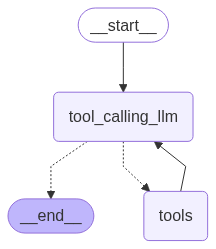

In [39]:
from langgraph.checkpoint.memory import MemorySaver
memory= MemorySaver()
graph_memory=builder.compile(checkpointer=memory)


display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [40]:
## specify the thread

config={"configurable":{"thread_id":"1"}}

## specify the input

messages=[HumanMessage(content="add 12  and 13")]
messages=graph_memory.invoke({"messages":messages},config=config)

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

add 12  and 13
================================== Ai Message ==================================
Tool Calls:
  add (2kg1jnkas)
 Call ID: 2kg1jnkas
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

25


In [41]:

messages=[HumanMessage(content="add that number to 25")]
messages=graph_memory.invoke({"messages":messages},config=config)

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

add 12  and 13
================================== Ai Message ==================================
Tool Calls:
  add (2kg1jnkas)
 Call ID: 2kg1jnkas
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

25
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (es6h0vwzj)
 Call ID: es6h0vwzj
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

50


In [43]:

messages=[HumanMessage(content="now multiply that number by 2")]
messages=graph_memory.invoke({"messages":messages},config=config)

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

add 12  and 13
================================== Ai Message ==================================
Tool Calls:
  add (2kg1jnkas)
 Call ID: 2kg1jnkas
  Args:
    a: 12
    b: 13
================================= Tool Message =================================
Name: add

25
================================== Ai Message ==================================

25
================================ Human Message =================================

add that number to 25
================================== Ai Message ==================================
Tool Calls:
  add (es6h0vwzj)
 Call ID: es6h0vwzj
  Args:
    a: 25
    b: 25
================================= Tool Message =================================
Name: add

50
================================== Ai Message ==================================

50
================================ Human Message =================================

add that number to 25
=================